<a href="https://colab.research.google.com/github/isabellamattar/FIAP-Data-Science/blob/main/aula_09_kmeans_Exerc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

<h1 style="text-align: center;"><strong>IA & Deep Learning Applications</strong></h1>
<h2 style="text-align: center;"><strong>Aula 09 - KMeans</strong></h2>

<h4 style="text-align: center;"><strong>FIAP - 2025</strong></h4>
<br>
<br>

---

**Exercício**

Aplicar e comparar KMeans (não supervisionado) e KNN Classifier (supervisionado) no dataset load_breast_cancer() do scikit-learn, avaliando o impacto do PCA no desempenho final.

**Dataset**

Use sklearn.datasets.load_breast_cancer().




**Protocolo:**

- Faça um único split treino/teste 80/20: test_size=0.20, com stratify=y e random_state fixo.
- Use StandardScaler em todos os cenários (fit somente no treino, transform no treino e no teste).
- Use as mesmas métricas e o mesmo conjunto de teste para comparar todos os cenários.
   - Métricas obrigatórias:
   - Matriz de confusão
   - Accuracy
   - F1-score (para a classe positiva padrão = 1)

**Observações:**

**Por que usar holdout (80/20) no KMeans, mesmo sendo não supervisionado?**

O KMeans não precisa de y para treinar, porém neste exercício utilizaremos um split treino/teste (80/20) para garantir comparação justa com o KNN e para avaliar o desempenho em dados não vistos.

O protocolo será:
1) Treinar o KMeans apenas com X_train (desconsiderando totalmente y_train no treinamento do algoritmo).
2) Obter os rótulos de cluster no treino (clusters_train) e no teste (clusters_test).
3) Como os clusters do KMeans (0, 1, 2, …) não correspondem diretamente às classes reais do dataset (0/1), o y será usado apenas para avaliação, para criar um mapeamento cluster → classe usando somente o conjunto de treino:
  - Algoritmo Húngaro (Hungarian Algorithm) para encontrar o pareamento ótimo entre clusters e classes, maximizando o número de acertos no treino.
4) Aplicar esse mapeamento nos clusters do teste para gerar y_pred_kmeans e então calcular a matriz de confusão e métricas comparando y_pred_kmeans com y_test.

Em resumo: o KMeans treina sem rótulo; o y entra somente para padronizar os clusters em classes e permitir uma comparação direta (matriz de confusão, Accuracy e F1) com o KNN no mesmo conjunto de teste.

Importante: o mapeamento cluster→classe deve ser definido apenas no treino. Fazer o mapeamento usando o teste caracteriza data leakage.

**Exercício 1 — KMeans sem PCA**

**Tarefa**
1) Carregue o dataset e faça o split 80/20.
2) Padronize as features com StandardScaler.
   - Teste n_clusters no intervalo k = 2 a 10 e calcule:
   - Silhouette score (obrigatório)
3) Inertia (opcional, para análise de “cotovelo”)
4) Escolha o melhor k e justifique a escolha.
5) Treine o KMeans final com o melhor k no treino.
6) Faça o mapeamento cluster→classe (majority vote no treino).
7) Avalie no teste: matriz de confusão + accuracy + f1.

**Entregáveis**
- Gráfico silhouette × k
- Gráfico inertia × k
- Melhor k e justificativa
- Matriz de confusão + Accuracy + F1

**Exercício 2 — KMeans com PCA**

**Tarefa**
1) Reaplique o pipeline do Exercício 1, mas agora inclua PCA após o scaler.
2) Use um dos critérios abaixo para PCA:
- n_components=0.95 (recomendado), ou
- n_components=2 (se quiser priorizar visualização)
3) Repita a busca de n_clusters (k = 2 a 10) e a avaliação completa.

**Entregáveis**
- Critério do PCA usado e:
   - se 0.95: número de componentes resultante e variância explicada acumulada
- Gráfico silhouette × k
- Melhor k e justificativa
- Matriz de confusão + Accuracy + F1

**Exercício 3 — KNN sem PCA**

**Tarefa**
1) Reuse o mesmo split 80/20 e o mesmo pré-processamento (scaler).
2) Teste n_neighbors no intervalo k = 1 a 30 usando cross-validation no treino (StratifiedKFold, 5 folds), com métrica F1.
3) Escolha o melhor k e justifique.
4) Treine o KNN final no treino e avalie no teste: matriz de confusão + métricas.

**Entregáveis**
- Gráfico F1 (CV no treino) × k
- Melhor k e justificativa
- Matriz de confusão + Accuracy + F1

**Exercício 4 — KNN com PCA**

**Tarefa**
1) Scaler → PCA (mesmo critério do Exercício 2).
2) Repita a busca de n_neighbors (k = 1 a 30) com CV no treino (F1).
3) Treine o KNN final e avalie no teste.

**Entregáveis**
- Gráfico F1 (CV no treino) × k
- Melhor k e justificativa
- Matriz de confusão + Accuracy + F1

**Exercício 5 — Comparação final (4 cenários)**

**Tarefa**

Monte uma tabela comparando os quatro cenários:
1) KMeans sem PCA
2) KMeans com PCA
3) KNN sem PCA
4) KNN com PCA

Para cada cenário, reporte:
- Melhor hiperparâmetro escolhido (n_clusters ou n_neighbors)
- Accuracy
- F1
- Matriz de confusão

Em seguida, responda:
1) Qual cenário teve melhor desempenho?
2) PCA ajudou ou atrapalhou KMeans e KNN? Por quê?
3) Por que KNN tende a superar KMeans quando o objetivo é classificação?

**Entregáveis**
- Tabela comparativa final
- Respostas das 3 perguntas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score, confusion_matrix, accuracy_score, f1_score
from scipy.optimize import linear_sum_assignment

# Carregar dados
data = load_breast_cancer()
X, y = data.data, data.target

# Split 80/20 com estratificação
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Padronização (fit apenas no treino)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

In [2]:
def get_cluster_mapping(y_true, cluster_labels):
    n_clusters = len(np.unique(cluster_labels))
    n_classes = len(np.unique(y_true))
    matrix = np.zeros((n_clusters, n_classes))
    for i in range(n_clusters):
        for j in range(n_classes):
            matrix[i, j] = -np.sum((cluster_labels == i) & (y_true == j))
    row_ind, col_ind = linear_sum_assignment(matrix)
    return {row: col for row, col in zip(row_ind, col_ind)}

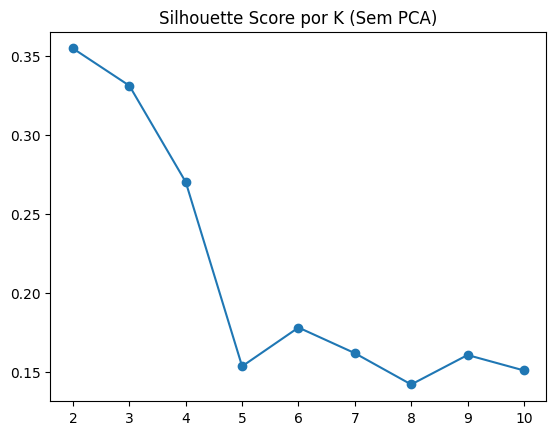

KMeans (Sem PCA) Accuracy: 0.9298


In [3]:
k_range = range(2, 11)
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train)
    sil_scores.append(silhouette_score(X_train, labels))

# Plotar Silhouette
plt.plot(k_range, sil_scores, marker='o')
plt.title('Silhouette Score por K (Sem PCA)')
plt.show()

# Treinar modelo final com k=2 (melhor resultado)
best_k_km = 2
kmeans_final = KMeans(n_clusters=best_k_km, random_state=42, n_init=10)
train_clusters = kmeans_final.fit_predict(X_train)
mapping = get_cluster_mapping(y_train, train_clusters)

# Avaliação
y_pred_km = np.array([mapping[c] for c in kmeans_final.predict(X_test)])
print(f"KMeans (Sem PCA) Accuracy: {accuracy_score(y_test, y_pred_km):.4f}")

In [4]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Número de componentes: {pca.n_components_}")

# Repetir busca de K e avaliação (similar ao passo anterior, usando X_train_pca)
# ...

Número de componentes: 10


In [5]:
k_neighbors = range(1, 31)
cv_scores = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=skf, scoring='f1')
    cv_scores.append(scores.mean())

best_k_knn = k_neighbors[np.argmax(cv_scores)]
print(f"Melhor K para KNN: {best_k_knn}")

# Treino Final
knn_final = KNeighborsClassifier(n_neighbors=best_k_knn)
knn_final.fit(X_train, y_train)
y_pred_knn = knn_final.predict(X_test)

Melhor K para KNN: 10


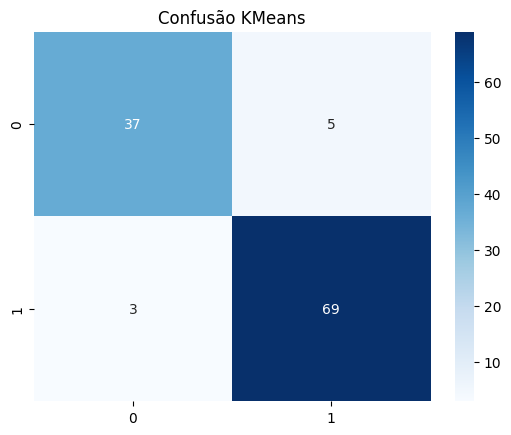

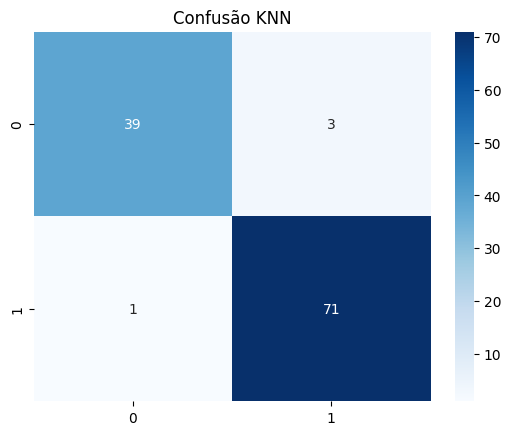

In [6]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.show()

plot_cm(y_test, y_pred_km, "Confusão KMeans")
plot_cm(y_test, y_pred_knn, "Confusão KNN")